### Model dry run with t cell example

### Generate model inputs

In [2]:
import pickle
import numpy as np

import zipfile
from io import BytesIO
import tifffile

import os

In [6]:
cvat_base_dir = "/gladstone/engelhardt/lab/jutran/lci/MarsonImagingPipeline/data/ground_truth_tracking_annotations/cvat_annotations/TCR-T/"
example_crop = 'B4_t50t100y200y350x750x900'
example_well_id = 'B4'

cvat_tracks = tifffile.imread(os.path.join(cvat_base_dir, example_well_id, example_crop, 'ALL_tracks.tiff'))
cell_type_dict = pickle.load(open(os.path.join(cvat_base_dir, example_well_id, example_crop, f'full_cell_type_dict.pkl'), "rb"))

In [7]:
def filter_tracks(track_type, tracks, type_dict):
    """Filter tracks to only contain tracks of the desired type

    Args:
        track_type (str): Type of track to filter for, matching a key in type_dict
        tracks (np.ndarray): Tracked cell mask [T, Y, X]
        type_dict (dict): Dictionary mapping cell id to cell type
    """

    valid_ids = [cell_id for cell_id, cell_type in type_dict.items() if cell_type == track_type]

    filtered_tracks = tracks.copy()
    filtered_tracks[~np.isin(filtered_tracks, valid_ids)] = 0
    
    return filtered_tracks

In [ ]:
type_tracks_per_well = {}
for cell_type in ['cancer', 't_cell']:
    type_tracks_per_well[cell_type] = filter_tracks(cell_type, cvat_tracks, cell_type_dict)

In [12]:
t_cell_tracks = type_tracks_per_well['t_cell']

In [15]:
data = {}

T = t_cell_tracks.shape[0]
all_cell_ids = np.unique(t_cell_tracks[t_cell_tracks > 0])
all_cell_ids.sort()
num_cells = len(all_cell_ids)
id_to_col = {int(cid): i for i, cid in enumerate(all_cell_ids)}

print(f"T={T}, num_cells={num_cells}")

# Initialize all masks
active_mask = np.zeros((T, num_cells), dtype=bool)
is_division_mask = np.zeros((T, num_cells), dtype=bool)
is_new_root_mask = np.zeros((T, num_cells), dtype=bool)
parent_indices = np.zeros((T, num_cells), dtype=np.int32)

# Make active_mask from t_cell_tracks
for t in range(T):
    t_cell_frame = t_cell_tracks[t]
    frame_ids = np.unique(t_cell_frame[t_cell_frame > 0])
    for cid in frame_ids:
        active_mask[t, id_to_col[int(cid)]] = True

# 4. Build is_new_root_mask, parent_indices (keep is_division_mask as all False)
for cid, col in id_to_col.items():
    active_frames = np.where(active_mask[:, col])[0]
    if len(active_frames) == 0:
        print(f"Warning: Cell ID {cid} (col {col}) is never active in active_mask. Skipping.")
        continue

    first_frame = active_frames[0]

    # This cell is a root (appeared spontaneously or is the initial cell)
    is_new_root_mask[first_frame, col] = True
    parent_indices[first_frame, col] = col  # self

    # For all subsequent active frames, parent = self (cell continues)
    for t in active_frames[1:]:
        parent_indices[t, col] = col

data["parent_indices"] = parent_indices
data['active_mask'] = active_mask
data["is_division_mask"] = is_division_mask
data["is_new_root_mask"] = is_new_root_mask

# 5. Summary
print(f"active_mask shape:       {active_mask.shape}")
print(f"parent_indices shape:    {parent_indices.shape}")
print(f"is_division_mask shape:  {is_division_mask.shape}")
print(f"is_new_root_mask shape:  {is_new_root_mask.shape}")
print(f"Division events (daughters): {is_division_mask.sum()}")
print(f"Root cells:                  {is_new_root_mask.sum()}")

T=50, num_cells=110
active_mask shape:       (50, 110)
parent_indices shape:    (50, 110)
is_division_mask shape:  (50, 110)
is_new_root_mask shape:  (50, 110)
Division events (daughters): 0
Root cells:                  110


In [20]:
import matplotlib.pyplot as plt

def visualize_full_lineage(data):
    """
    Visualizes the tree lineage vertically.
    Y-axis: Time (starts at 0 at the top, goes down).
    X-axis: Unique Cell ID.
    """
    parent_indices = np.array(data['parent_indices'])
    active_mask = np.array(data['active_mask'])
    is_new_root = np.array(data['is_new_root_mask'])
    is_division = np.array(data['is_division_mask'])
    
    T, MaxCells = active_mask.shape
    
    plt.figure(figsize=(12, 10))
    
    # 1. Draw Cell Tracks (Vertical Lines)
    # We iterate by ID to draw contiguous vertical lines for each unique cell
    # Limit visualization to first 64 cells
    max_cells_to_show = MaxCells
    
    for cell_id in range(min(MaxCells, max_cells_to_show)):
        # Find time points where this cell is active
        active_times = np.where(active_mask[:, cell_id])[0]
        
        if len(active_times) > 0:
            # Draw the life of the cell vertically
            # X = Cell ID (Constant), Y = Time (Variable)
            plt.plot([cell_id] * len(active_times), active_times, 
                     marker='o', markersize=4, linewidth=3, alpha=0.7, 
                     color='skyblue', label='Cell Life' if cell_id == 0 else "")
            
            # Label the start of the track
            t_start = active_times[0]
            
            # 2. Draw Connections to Parents (Upwards)
            if t_start > 0:
                parent_id = parent_indices[t_start, cell_id]
                
                # Only draw parent connections if parent is also in the visible range
                if parent_id < max_cells_to_show:
                    # Check if this is a "New Root" (Spontaneous) or a Child
                    if is_new_root[t_start, cell_id]:
                        # Star marker for spontaneous appearance
                        plt.plot(cell_id, t_start, marker='*', color='green', markersize=12, label='New Root' if cell_id==0 else "")
                    else:
                        # Draw connection line from Parent(t-1) to Child(t)
                        # Parent is at (parent_id, t_start - 1)
                        # Child is at (cell_id, t_start)
                        plt.plot([parent_id, cell_id], [t_start - 1, t_start], 
                                 color='gray', linestyle='--', linewidth=1, alpha=0.5)
                        
                        # If this was a division, mark the birth point
                        if is_division[t_start, cell_id]:
                             plt.plot(cell_id, t_start, marker='^', color='red', markersize=8, label='Division Child' if cell_id==0 else "")

    plt.ylabel("Time Step (t=0 at Top)")
    plt.xlabel("Unique Cell ID (Column Index)")
    plt.title("Lineage Tree Visualization (Vertical Flow)")
    
    # Invert Y axis so time goes down
    plt.gca().invert_yaxis()
    
    # Grid and Ticks
    plt.grid(True, alpha=0.3)
    # Crop x-axis to show only first 64 cells
    plt.xlim(-0.5, max_cells_to_show - 0.5)
    plt.xticks(np.arange(0, max_cells_to_show, 1))
    plt.yticks(np.arange(0, T, 1))
    #plt.axis('off')
    
    # Create a custom legend manually to avoid duplicate labels
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='skyblue', lw=3, marker='o', label='Active Cell (Vertical)'),
        Line2D([0], [0], color='gray', lw=1, linestyle='--', label='Parent Link'),
        Line2D([0], [0], color='red', lw=0, marker='^', label='Born from Division'),
        Line2D([0], [0], color='green', lw=0, marker='*', label='Spontaneous Root')
    ]
    plt.legend(handles=custom_lines, loc='upper right')
    
    plt.tight_layout()
    plt.show()

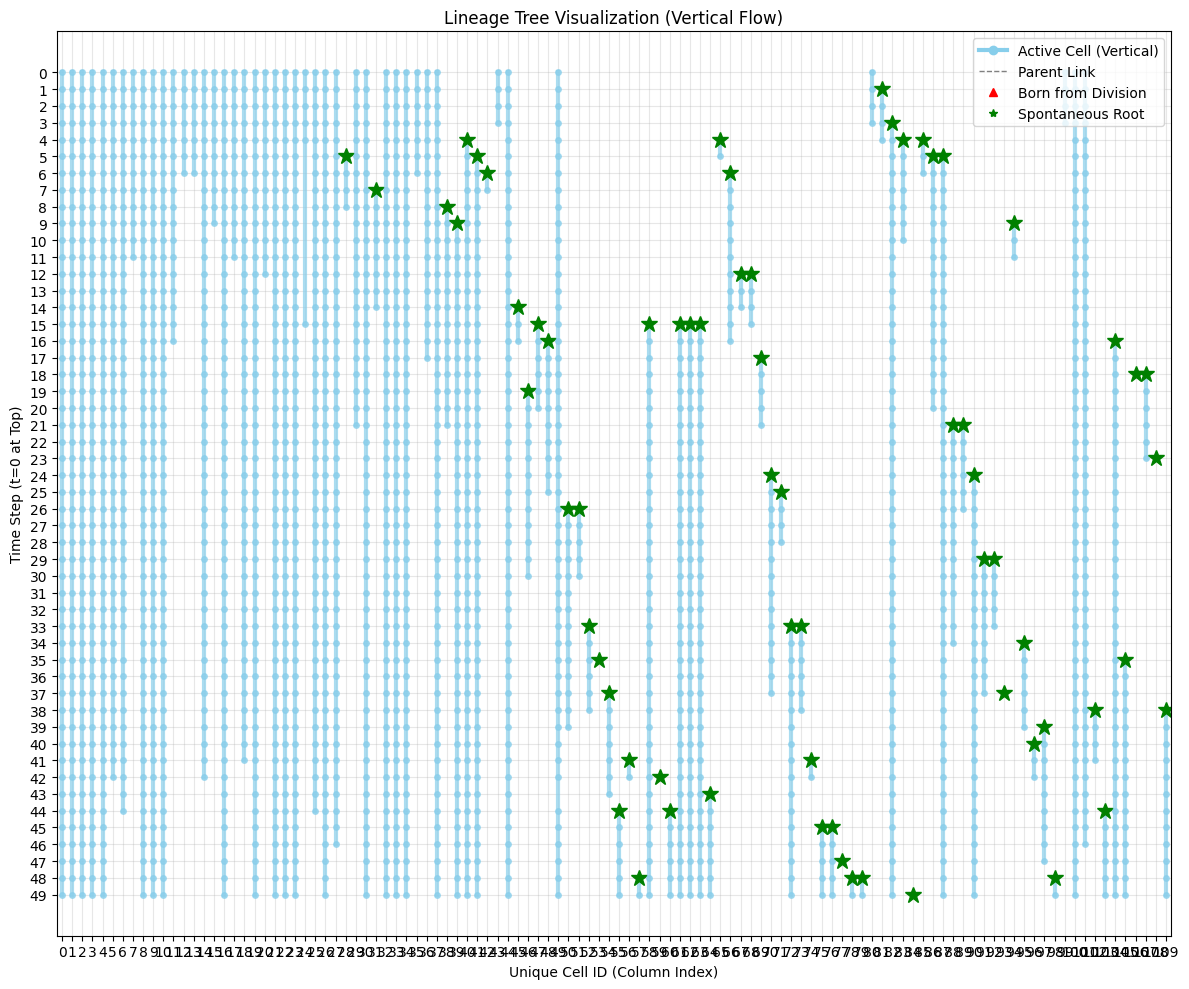

In [21]:
visualize_full_lineage(data)

In [63]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [42]:
# visualize emissions
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_t_cell_emissions_array.npy")

In [45]:
reshaped_emissions = emissions.reshape(-1, emissions.shape[-1])  # [T*num_cells, num_features]
reshaped_emissions.shape

(5500, 3)

In [64]:
for i in range(5):
    kmeans = KMeans(n_clusters=i+2, random_state=0).fit(reshaped_emissions)
    score = silhouette_score(reshaped_emissions, kmeans.labels_)
    print(f"Silhouette Score for {i+2} clusters: {score:.4f}")

Silhouette Score for 2 clusters: 0.7983
Silhouette Score for 3 clusters: 0.7050
Silhouette Score for 4 clusters: 0.7083
Silhouette Score for 5 clusters: 0.7145
Silhouette Score for 6 clusters: 0.7198


In [59]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(reshaped_emissions)

In [60]:
kmeans.labels_

array([0, 0, 0, ..., 0, 0, 2], dtype=int32)

In [61]:
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(reshaped_emissions)
print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.84799972 0.11243416]
0.9604338811418808


Text(0.5, 1.0, 'PCA of T Cell Emissions')

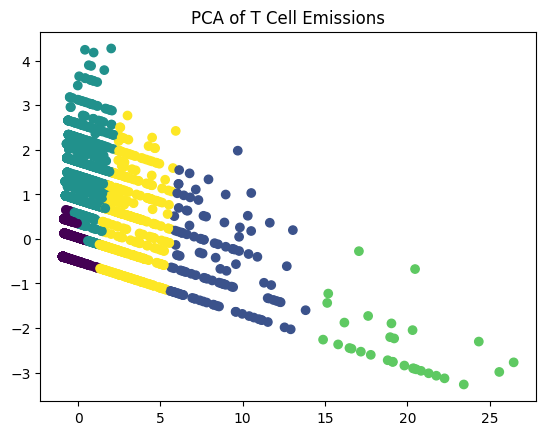

In [62]:
colors = kmeans.labels_

plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=colors, cmap='viridis')
plt.title("PCA of T Cell Emissions")


### Initialize and run model

In [22]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/jutran/lci/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


True

In [23]:
num_states = 3
emission_dim = 3
num_lags = 1

In [24]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_t_cell_emissions_array.npy")

In [25]:
emissions.shape, is_division_mask.shape, is_new_root_mask.shape, parent_indices.shape, active_mask.shape

((50, 110, 3), (50, 110), (50, 110), (50, 110), (50, 110))

In [26]:
arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions)
inputs = arhmm.compute_inputs(
    jnp.array(emissions),
    jnp.array(parent_indices),
    jnp.array(is_division_mask),
    jnp.array(is_new_root_mask),
    jnp.array(active_mask),
)

In [27]:
batched_emissions = jnp.stack([emissions,emissions])
batched_inputs = jnp.stack([inputs,inputs])
batched_parent_indices = jnp.stack([parent_indices, parent_indices])
batched_is_division_mask = jnp.stack([is_division_mask, is_division_mask])
batched_active_mask = jnp.stack([active_mask, active_mask])
batched_is_new_root_mask = jnp.stack([is_new_root_mask, is_new_root_mask])


In [65]:
batched_emissions = emissions
batched_inputs = inputs
batched_parent_indices = parent_indices
batched_is_division_mask = is_division_mask
batched_active_mask = active_mask
batched_is_new_root_mask = is_new_root_mask

In [66]:
fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;00:00]</div>

In [67]:
fitted_params

ParamsLinearTreeARHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.69278944, 0.00092427, 0.3062863 ], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.09794349, 0.19419625, 0.70786023],
       [0.12255464, 0.3286298 , 0.5488156 ],
       [0.02068678, 0.06877116, 0.910542  ]], dtype=float32)), division_transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.3333332, 0.3333332, 0.3333332],
       [0.3333332, 0.3333332, 0.3333332],
       [0.3333332, 0.3333332, 0.3333332]], dtype=float32)), emissions=ParamsLinearRegressionHMMEmissions(weights=Array([[[ 1.04088731e-01,  5.41052878e-01,  2.04817891e-01],
        [-1.68414824e-02,  2.99286246e-01, -1.01004176e-01],
        [-3.13690454e-02, -1.57701254e-01,  6.01691008e-01]],

       [[ 4.90634948e-01, -1.44184077e+00, -1.34259760e+00],
        [-2.96258703e-02,  4.25584167e-01,  1.07141770e-01],
        [-8.39662924e-03,  1.47275394e-02,  6.25943840e-01]],

       [[ 5.35506904e-01, 

In [31]:
from models.tarhmm import tree_hmm_two_filter_smoother

In [68]:
# Compute the posterior distribution of the latent states
input_fwd = arhmm._inference_args(params, emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])

posterior = tree_hmm_two_filter_smoother(*input_fwd)

In [34]:
posterior

TreeHMMPosterior(marginal_loglik=Array(-13156.699, dtype=float32), filtered_probs=Array([[[3.6674310e-06, 0.0000000e+00, 9.9999636e-01],
        [3.6674310e-06, 0.0000000e+00, 9.9999636e-01],
        [4.0256095e-06, 0.0000000e+00, 9.9999601e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[8.1865679e-08, 0.0000000e+00, 9.9999994e-01],
        [1.6020656e-05, 0.0000000e+00, 9.9998397e-01],
        [2.7771210e-07, 0.0000000e+00, 9.9999970e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[9.5493469e-08, 0.0000000e+00, 9.9999994e-01],
        [6.2248737e-06, 0.0000000e+00, 9.9999380e-01],
        [8.2719794e-08, 0.0000000e+00, 9.9999994e-01],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+

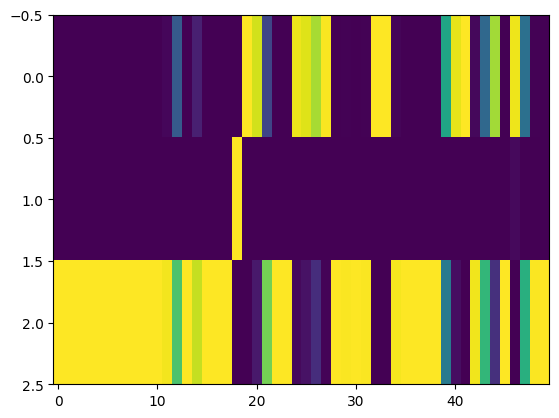

In [69]:
# T x C x features

plt.imshow(posterior.smoothed_probs[:,10,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

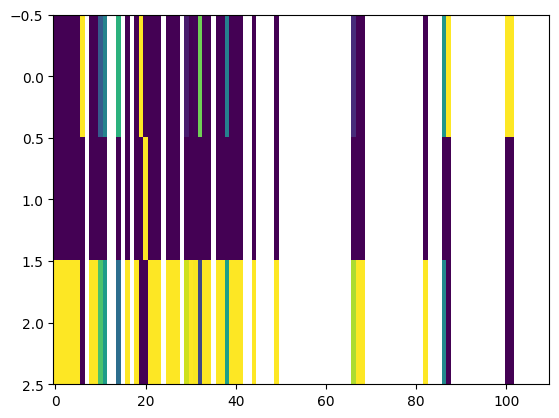

In [71]:
plt.imshow(posterior.smoothed_probs[12,:,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

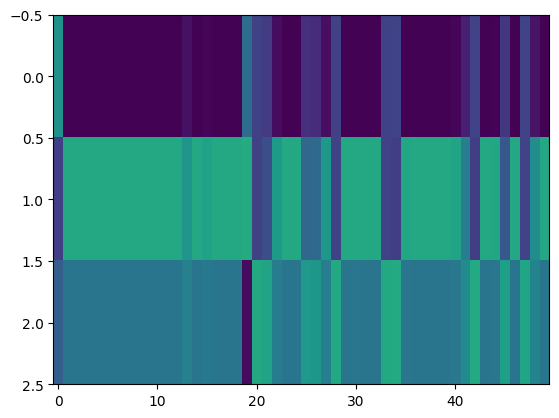

In [41]:
plt.imshow(posterior.predicted_probs[:,10,:].T, aspect="auto", interpolation="none", vmin=0, vmax=1)
#plt.xlim(4,15)

In [72]:
posterior.smoothed_probs.shape

(50, 110, 3)

In [79]:
state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

In [80]:
state_assignments

Array([[2, 2, 2, ..., 0, 0, 0],
       [2, 2, 2, ..., 0, 0, 0],
       [2, 2, 2, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 0, 0, 2],
       [2, 2, 2, ..., 0, 0, 2],
       [2, 2, 2, ..., 0, 0, 2]], dtype=int32)

In [81]:
np.save("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_t_cell_state_assignments.npy", state_assignments)